In [1]:
import yfinance as yf
import numpy as np
import pandas as pd


tickers = [
    'AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA',
    'JPM', 'BAC', 'GS', 'WFC', 'MS',
    'JNJ', 'UNH', 'PFE', 'MRK', 'ABBV',
    'XOM', 'CVX', 'COP', 'SLB', 'EOG',
    'PG', 'KO', 'PEP', 'WMT', 'COST',
    'HD', 'MCD', 'NKE', 'SBUX', 'TGT'
]

raw = yf.download(tickers, start='2020-01-01', end='2025-12-31', progress=False)['Close']
returns = np.log(raw / raw.shift(1)).dropna()
returns.head()


Ticker,AAPL,ABBV,AMZN,BAC,COP,COST,CVX,EOG,GOOG,GS,...,PEP,PFE,PG,SBUX,SLB,TGT,UNH,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,-0.009769,-0.009537,-0.012213,-0.020982,0.003659,0.000823,-0.003465,0.010051,-0.004919,-0.011763,...,-0.001400,-0.005380,-0.006748,-0.005837,0.009662,-0.010445,-0.010171,-0.006158,-0.008867,-0.008072
2020-01-06,0.007937,0.007861,0.014776,-0.001434,0.011802,0.000274,-0.003394,0.039791,0.024358,0.010182,...,0.003827,-0.001285,0.001386,-0.007911,0.006390,-0.009503,0.006918,-0.006008,-0.002038,0.007649
2020-01-07,-0.004714,-0.005721,0.002089,-0.006622,0.000000,-0.001577,-0.012852,0.009565,-0.000624,0.006561,...,-0.015843,-0.003349,-0.006211,-0.003068,-0.005157,0.001779,-0.006055,-0.008321,-0.009308,-0.008217
2020-01-08,0.015958,0.007062,-0.007839,0.010059,-0.023438,0.011398,-0.011489,-0.022081,0.007850,0.009593,...,0.005136,0.007968,0.004254,0.011542,-0.029995,-0.003236,0.020865,0.003034,-0.003438,-0.015195
2020-01-09,0.021018,0.007678,0.004788,0.001714,0.017251,0.015923,-0.001615,0.010365,0.010984,0.020152,...,0.000668,-0.004362,0.010878,0.018394,0.011354,0.000810,-0.005694,-0.001705,0.010278,0.007627


In [2]:
mu = returns.mean().values
sigma = returns.std().values
Sigma = returns.cov().values

mu_ann = mu * 252
sigma_ann = sigma * np.sqrt(252)

mu_norm = mu_ann / sigma_ann
R_tilde = ((returns - returns.mean()) / returns.std()).values

print("mu_annual (first 5):", np.round(mu_ann[:5], 4))
print("sigma_annual (first 5):", np.round(sigma_ann[:5], 4))
print("mu_norm (first 5):", np.round(mu_norm[:5], 4))
print("Sigma diagonal (first 5):", np.round(np.diag(Sigma)[:5], 6))
print("Sigma min eigenvalue:", np.round(np.linalg.eigvalsh(Sigma).min(), 6))

mu_annual (first 5): [0.222  0.1993 0.15   0.0981 0.0974]
sigma_annual (first 5): [0.3175 0.2514 0.3568 0.3437 0.4281]
mu_norm (first 5): [0.6992 0.7927 0.4202 0.2854 0.2276]
Sigma diagonal (first 5): [0.0004   0.000251 0.000505 0.000469 0.000727]
Sigma min eigenvalue: 4e-05


In [3]:
def portfolio_return(subset, mu):
    # equal weight portfolio return for a given subset of asset indices
    return np.mean(mu[list(subset)])

def portfolio_variance(subset, Sigma):
    # equal weight portfolio variance for a given subset of asset indices
    idx = list(subset)
    sub_Sigma = Sigma[np.ix_(idx, idx)]
    k = len(idx)
    w = np.ones(k) / k
    return w @ sub_Sigma @ w

test_subset = [0, 1, 2, 3, 4]
print(f"Return: {round(portfolio_return(test_subset, mu_ann), 4)}")
print(f"Variance: {round(portfolio_variance(test_subset, Sigma), 6)}")
print(f"Volatility: {round(np.sqrt(portfolio_variance(test_subset, Sigma)) * np.sqrt(252), 4)}")


Return: 0.1534
Variance: 0.000225
Volatility: 0.2381


# A (BRUTE FORCE)

In [4]:
from itertools import combinations
import time

def brute_force(n, k, mu, Sigma, sigma2_max):
    # Enumerate all C(n,k) subsets.
    # Returns best subset, its return, and runtime.
    
    assets = list(range(n))
    best_return = -np.inf
    best_subset = None
    all_portfolios = []
    
    start = time.time()
    
    for subset in combinations(assets, k):
        ret = portfolio_return(subset, mu)
        var = portfolio_variance(subset, Sigma)
        all_portfolios.append((subset, ret, var))
        
        if var <= sigma2_max and ret > best_return:
            best_return = ret
            best_subset = subset
    
    runtime = time.time() - start
    
    # if no subset is feasible, just return best return ignoring constraint
    if best_subset is None:
        best_subset, best_return, _ = max(all_portfolios, key=lambda x: x[1])
    
    return best_subset, best_return, runtime, all_portfolios

n_test, k_test = 20, 5
assets_test = list(range(n_test))

print(f"Computing median var across C({n_test}, {k_test}) portfolios.")
variances = [portfolio_variance(s, Sigma[:n_test, :n_test]) for s in combinations(assets_test, k_test)]
sigma2_max = np.median(variances)
print(f"sigma2_max set to: {sigma2_max:.6f}")
print(f"Annualized vol budget: {np.sqrt(sigma2_max * 252):.4f}")



Computing median var across C(20, 5) portfolios.
sigma2_max set to: 0.000215
Annualized vol budget: 0.2327


In [5]:
from math import comb

def greedy(n, k, mu, Sigma, sigma2_max):
    # sequentially add the asset that maximally improves return s.t. risk constraint
    # if no feasible asset exists at a step then add the highest return asset regardless of constraint

    available = list(range(n))
    selected = []
    
    for _ in range(k):
        best_ret = -np.inf
        best_asset = None
        
        # try to find feasible addition
        for asset in available:
            candidate = selected + [asset]
            var = portfolio_variance(candidate, Sigma)
            ret = portfolio_return(candidate, mu)
            if var <= sigma2_max and ret > best_ret:
                best_ret = ret
                best_asset = asset
        
        if best_asset is None:
            best_asset = max(available, key=lambda a: mu[a])
        
        selected.append(best_asset)
        available.remove(best_asset)
    
    return tuple(selected), portfolio_return(selected, mu)


# experiment A
ns = [10, 15, 20, 25, 30]
ks = [5, 7, 10]
results_A = []

for n in ns:
    for k in ks:
        mu_n = mu_ann[:n]
        Sigma_n = Sigma[:n, :n]
        
        n_combos = comb(n, k)
        
        # brute force
        best_sub, best_ret, runtime, _ = brute_force(n, k, mu_n, Sigma_n, sigma2_max)
        
        # greedy
        greedy_sub, greedy_ret = greedy(n, k, mu_n, Sigma_n, sigma2_max)
        
        # greedy gap
        gap = (best_ret - greedy_ret) / abs(best_ret) if best_ret != 0 else 0
        
        results_A.append({
            'n': n,
            'k': k,
            'C(n,k)': n_combos,
            'best_return': round(best_ret, 4),
            'greedy_return': round(greedy_ret, 4),
            'greedy_gap': round(gap * 100, 2),
            'runtime_s': round(runtime, 3)
        })
        
        print(f"n={n}, k={k}: C({n},{k})={n_combos:,} | optimal={best_ret:.4f} | greedy={greedy_ret:.4f} | gap={gap*100:.2f}% | time={runtime:.3f}s")

n=10, k=5: C(10,5)=252 | optimal=0.2242 | greedy=0.2242 | gap=0.00% | time=0.016s
n=10, k=7: C(10,7)=120 | optimal=0.1956 | greedy=0.1956 | gap=0.00% | time=0.007s
n=10, k=10: C(10,10)=1 | optimal=0.1633 | greedy=0.1633 | gap=-0.00% | time=0.000s
n=15, k=5: C(15,5)=3,003 | optimal=0.2242 | greedy=0.2038 | gap=9.12% | time=0.110s
n=15, k=7: C(15,7)=6,435 | optimal=0.2054 | greedy=0.1975 | gap=3.83% | time=0.258s
n=15, k=10: C(15,10)=3,003 | optimal=0.1734 | greedy=0.1731 | gap=0.15% | time=0.140s
n=20, k=5: C(20,5)=15,504 | optimal=0.2731 | greedy=0.2071 | gap=24.18% | time=0.715s
n=20, k=7: C(20,7)=77,520 | optimal=0.2585 | greedy=0.2078 | gap=19.61% | time=3.439s
n=20, k=10: C(20,10)=184,756 | optimal=0.2392 | greedy=0.2392 | gap=0.00% | time=10.231s
n=25, k=5: C(25,5)=53,130 | optimal=0.2731 | greedy=0.2071 | gap=24.18% | time=2.746s
n=25, k=7: C(25,7)=480,700 | optimal=0.2585 | greedy=0.2078 | gap=19.61% | time=28.104s
n=25, k=10: C(25,10)=3,268,760 | optimal=0.2392 | greedy=0.2392 

KeyboardInterrupt: 

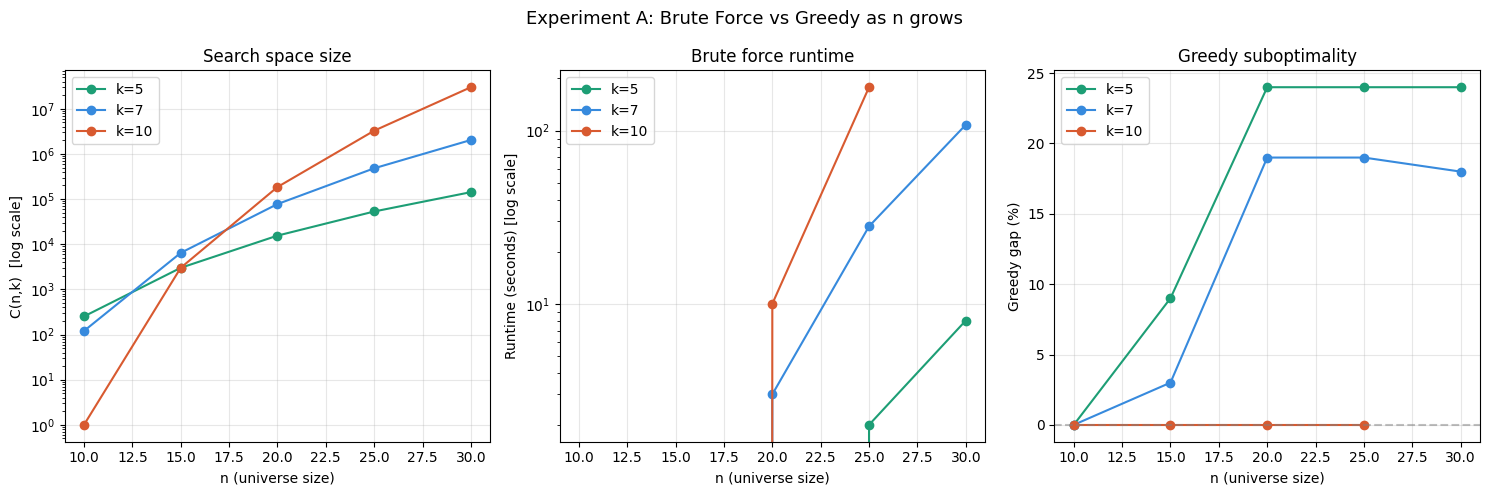

In [6]:
import matplotlib.pyplot as plt

results = [
    (a['n'], a['k'], a['best_return'], a['greedy_return'], a['greedy_gap'], a['runtime_s'])
    for a in results_A
]

colors={'k=5': '#1D9E75', 'k=7': '#378ADD', 'k=10': '#D85A30'}

def get(results, n, k, field):
    fields = ['n','k','optimal','greedy','gap','runtime']
    idx = fields.index(field)
    for row in results:
        if row[0]==n and row[1]==k:
            return row[idx]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Experiment A: Brute Force vs Greedy as n grows', fontsize=13)


ax = axes[0]
for k in ks:
    combos = [comb(n, k) for n in ns]
    ax.semilogy(ns, combos, marker='o', label=f'k={k}', color=colors[f'k={k}'])
ax.set_xlabel('n (universe size)')
ax.set_ylabel('C(n,k)  [log scale]')
ax.set_title('Search space size')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for k in ks:
    runtimes = [get(results, n, k, 'runtime') for n in ns]
    ax.semilogy(ns, runtimes, marker='o', label=f'k={k}', color=colors[f'k={k}'])
ax.set_xlabel('n (universe size)')
ax.set_ylabel('Runtime (seconds) [log scale]')
ax.set_title('Brute force runtime')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
for k in ks:
    gaps = [get(results, n, k, 'gap') for n in ns]
    ax.plot(ns, gaps, marker='o', label=f'k={k}', color=colors[f'k={k}'])
ax.set_xlabel('n (universe size)')
ax.set_ylabel('Greedy gap (%)')
ax.set_title('Greedy suboptimality')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_A.png', dpi=150, bbox_inches='tight')
plt.show()

# EXPERIMENT C

Enumerating all C(20,5) portfolios...
Done. 15504 portfolios.


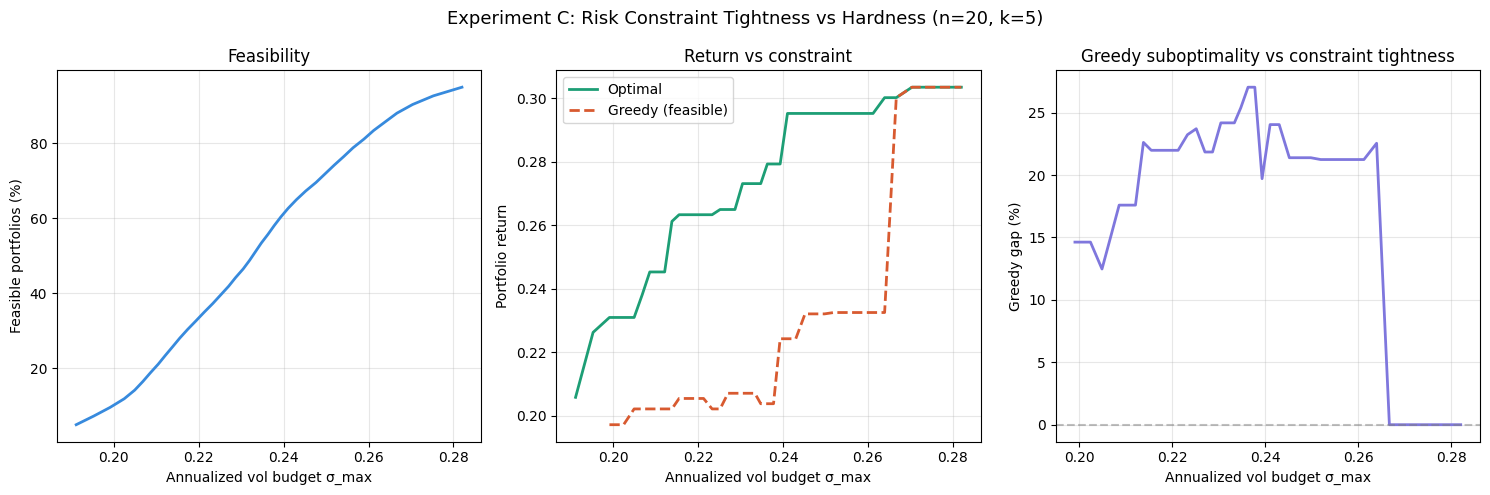

In [7]:
def greedy(n, k, mu, Sigma, sigma2_max):
    available = list(range(n))
    selected = []
    used_fallback = False
    
    for _ in range(k):
        best_ret = -np.inf
        best_asset = None
        
        for asset in available:
            candidate = selected + [asset]
            var = portfolio_variance(candidate, Sigma)
            ret = portfolio_return(candidate, mu)
            if var <= sigma2_max and ret > best_ret:
                best_ret = ret
                best_asset = asset
        
        if best_asset is None:
            used_fallback = True
            best_asset = max(available, key=lambda a: mu[a])
        
        selected.append(best_asset)
        available.remove(best_asset)
    
    return tuple(selected), portfolio_return(selected, mu), used_fallback


# Experiment C
n, k = 20, 5
mu_n = mu_ann[:n]
Sigma_n = Sigma[:n, :n]

print("Enumerating all C(20,5) portfolios...")
all_portfolios = []
for subset in combinations(range(n), k):
    ret = portfolio_return(subset, mu_n)
    var = portfolio_variance(subset, Sigma_n)
    all_portfolios.append((subset, ret, var))

all_vars = [p[2] for p in all_portfolios]
print(f"Done. {len(all_portfolios)} portfolios.")

sigma2_values = np.percentile(all_vars, np.linspace(5, 95, 40))
results_C = []

for sigma2_max in sigma2_values:
    feasible = [(s, r, v) for s, r, v in all_portfolios if v <= sigma2_max]
    n_feasible = len(feasible)

    if n_feasible == 0:
        continue

    best = max(feasible, key=lambda x: x[1])
    optimal_ret = best[1]

    greedy_sub, greedy_ret, used_fallback = greedy(n, k, mu_n, Sigma_n, sigma2_max)

    # only compute gap if greedy found a feasible solution
    if used_fallback:
        gap = np.nan
    else:
        gap = (optimal_ret - greedy_ret) / abs(optimal_ret) * 100

    results_C.append({
        'sigma2_max': sigma2_max,
        'sigma_max_annualized': np.sqrt(sigma2_max * 252),
        'n_feasible': n_feasible,
        'pct_feasible': n_feasible / len(all_portfolios) * 100,
        'optimal_ret': optimal_ret,
        'greedy_ret': greedy_ret,
        'gap': gap
    })

# convert to arrays
s2 = [r['sigma_max_annualized'] for r in results_C]
n_feas = [r['pct_feasible'] for r in results_C]
opt_ret = [r['optimal_ret'] for r in results_C]
greed_ret = [r['greedy_ret'] for r in results_C]
gaps = [r['gap'] for r in results_C]


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Experiment C: Risk Constraint Tightness vs Hardness (n=20, k=5)', fontsize=13)

ax = axes[0]
ax.plot(s2, n_feas, color='#378ADD', linewidth=2)
ax.set_xlabel('Annualized vol budget σ_max')
ax.set_ylabel('Feasible portfolios (%)')
ax.set_title('Feasibility')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(s2, opt_ret, color='#1D9E75', linewidth=2, label='Optimal')
s2_arr = np.array(s2)
gr_arr = np.array(greed_ret, dtype=float)
gaps_arr = np.array(gaps, dtype=float)
gr_masked = np.where(np.isnan(gaps_arr), np.nan, gr_arr)
ax.plot(s2, gr_masked, color='#D85A30', linewidth=2, linestyle='--', label='Greedy (feasible)')
ax.set_xlabel('Annualized vol budget σ_max')
ax.set_ylabel('Portfolio return')
ax.set_title('Return vs constraint')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(s2, gaps_arr, color='#7F77DD', linewidth=2)
ax.set_xlabel('Annualized vol budget σ_max')
ax.set_ylabel('Greedy gap (%)')
ax.set_title('Greedy suboptimality vs constraint tightness')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_C.png', dpi=150, bbox_inches='tight')
plt.show()

# EXPERIMENT F

In [8]:
# Experiment F: Solution landscape via random sampling
# WARNING: k=10 brute force + 100-trial random sampling took ~62 min on a MacBook.
# Run cells 0-9 and 11-13 first if short on time; come back to this cell last.
# Fix n=25, vary k in {3, 5, 7, 10}
# Know exact optimum from brute force, track how many random samples needed

import random

n_F = 25
ks_F = [3, 5, 7, 10]
n_trials = 100  # repeat 100 times and average

mu_F = mu_ann[:n_F]
Sigma_F = Sigma[:n_F, :n_F]

# first get exact optimum for each k via brute force
print("Computing exact optima...")
optima_F = {}
all_portfolios_F = {}

for k in ks_F:
    best_ret = -np.inf
    best_sub = None
    portfolios = []
    for subset in combinations(range(n_F), k):
        ret = portfolio_return(subset, mu_F)
        var = portfolio_variance(subset, Sigma_F)
        if var <= sigma2_max and ret > best_ret:
            best_ret = ret
            best_sub = subset
        portfolios.append((subset, ret, var))
    
    # fallback if nothing feasible
    if best_sub is None:
        best_sub, best_ret, _ = max(portfolios, key=lambda x: x[1])
    
    optima_F[k] = best_ret
    all_portfolios_F[k] = portfolios
    total = comb(n_F, k)
    print(f"k={k}: C({n_F},{k})={total:,} | optimal={best_ret:.4f}")

print()

# random sampling experiment
results_F = {}
thresholds = [0.90, 0.95, 0.99, 1.00]

for k in ks_F:
    total_combos = comb(n_F, k)
    optimal = optima_F[k]
    all_subs = [p[0] for p in all_portfolios_F[k]]
    
    # for each trial, shuffle and track best found so far
    curves = []  # each curve is best_return vs number of samples
    samples_to_threshold = {t: [] for t in thresholds}
    
    for trial in range(n_trials):
        shuffled = all_subs.copy()
        random.shuffle(shuffled)
        
        best_so_far = -np.inf
        curve = []
        hits = {t: None for t in thresholds}
        
        for m, subset in enumerate(shuffled):
            ret = portfolio_return(subset, mu_F)
            var = portfolio_variance(subset, Sigma_F)
            if var <= sigma2_max and ret > best_so_far:
                best_so_far = ret
            curve.append(best_so_far / optimal)
            
            # record first time we hit each threshold
            for t in thresholds:
                if hits[t] is None and best_so_far >= t * optimal:
                    hits[t] = m + 1  # 1-indexed
        
        curves.append(curve)
        for t in thresholds:
            if hits[t] is not None:
                samples_to_threshold[t].append(hits[t])
            else:
                samples_to_threshold[t].append(total_combos)
    
    # average discovery curve (truncate to first 5000 samples for plotting)
    max_plot = min(5000, total_combos)
    avg_curve = np.mean([c[:max_plot] for c in curves], axis=0)
    
    results_F[k] = {
        'total_combos': total_combos,
        'optimal': optimal,
        'avg_curve': avg_curve,
        'max_plot': max_plot,
        'samples_to_threshold': {
            t: np.mean(samples_to_threshold[t]) 
            for t in thresholds
        },
        'frac_needed': {
            t: np.mean(samples_to_threshold[t]) / total_combos 
            for t in thresholds
        }
    }
    
    print(f"k={k} | samples to 95% optimal: "
          f"{results_F[k]['samples_to_threshold'][0.95]:.0f} / {total_combos:,} "
          f"({results_F[k]['frac_needed'][0.95]*100:.2f}%)")

Computing exact optima...
k=3: C(25,3)=2,300 | optimal=0.3407
k=5: C(25,5)=53,130 | optimal=0.3035
k=7: C(25,7)=480,700 | optimal=0.2766


KeyboardInterrupt: 

In [ ]:
colors_F = {3: '#9B59B6', 5: '#1D9E75', 7: '#378ADD', 10: '#D85A30'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Experiment F: Solution Landscape via Random Sampling (n={n_F})', fontsize=13)

# Plot 1: Discovery curves — best return / optimal vs number of samples
ax = axes[0]
for k in ks_F:
    r = results_F[k]
    xs = np.arange(1, r['max_plot'] + 1)
    ax.plot(xs, r['avg_curve'], label=f'k={k}', color=colors_F[k], linewidth=2)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(y=0.95, color='gray', linestyle=':', alpha=0.4, linewidth=1)
ax.set_xlabel('Number of random samples')
ax.set_ylabel('Best return found / optimal')
ax.set_title('Discovery curve (avg over 100 trials)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Samples to 95% optimal vs k (log scale)
ax = axes[1]
samples_95 = [results_F[k]['samples_to_threshold'][0.95] for k in ks_F]
bars = ax.bar(
    [str(k) for k in ks_F], samples_95,
    color=[colors_F[k] for k in ks_F], alpha=0.85, edgecolor='white'
)
ax.set_yscale('log')
ax.set_xlabel('Portfolio size k')
ax.set_ylabel('Avg samples to reach 95% optimal [log scale]')
ax.set_title('Samples to 95% optimal vs k')
for bar, val in zip(bars, samples_95):
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.2,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=8.5)
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Fraction of C(n,k) needed to reach 95% of optimal
ax = axes[2]
fracs_95 = [results_F[k]['frac_needed'][0.95] * 100 for k in ks_F]
total_combos_F = [results_F[k]['total_combos'] for k in ks_F]
bars = ax.bar(
    [str(k) for k in ks_F], fracs_95,
    color=[colors_F[k] for k in ks_F], alpha=0.85, edgecolor='white'
)
ax.set_xlabel('Portfolio size k')
ax.set_ylabel('% of C(n,k) needed to reach 95% optimal')
ax.set_title(f'Fraction of search space needed (n={n_F})')
for bar, val, tot in zip(bars, fracs_95, total_combos_F):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
            f'{val:.1f}%\n(C={tot:,})', ha='center', va='bottom', fontsize=7.5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('experiment_F.png', dpi=150, bbox_inches='tight')
plt.show()


Enumerating all C(20,5) = 15,504 portfolios...
Feasible portfolios : 14,728 / 15,504 (95.0%)
Optimal return      : 0.3035


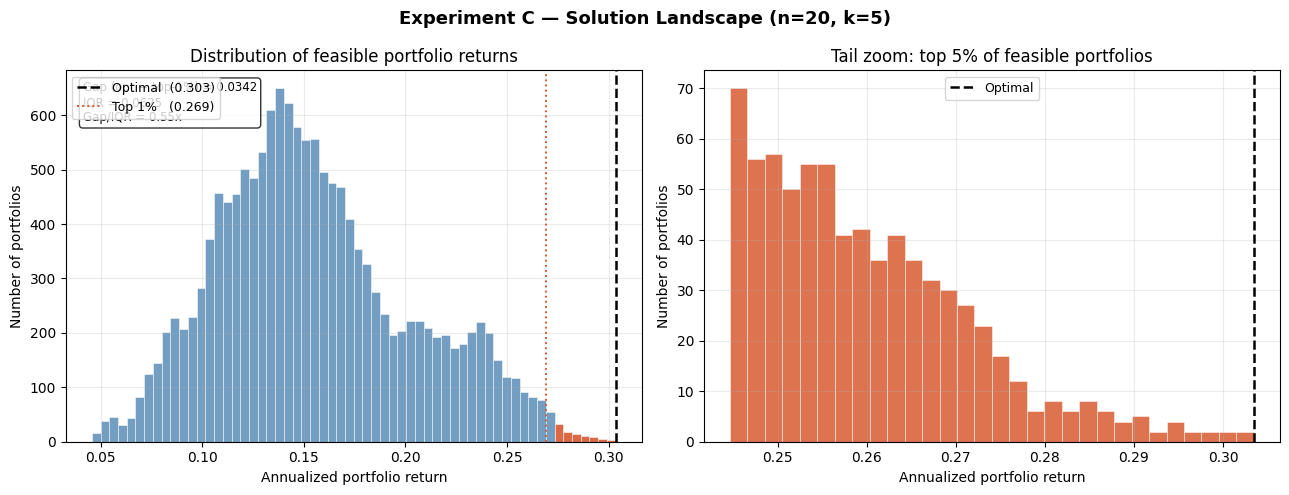

Saved: experiment_C_landscape.png
Top  1%:  148 portfolios, 10,878 pairs | mean overlap=0.522  median=0.600  std=0.151
Top  5%:  737 portfolios, 271,216 pairs | mean overlap=0.428  median=0.400  std=0.156
Top 10%: 1473 portfolios, 1,084,128 pairs | mean overlap=0.395  median=0.400  std=0.154


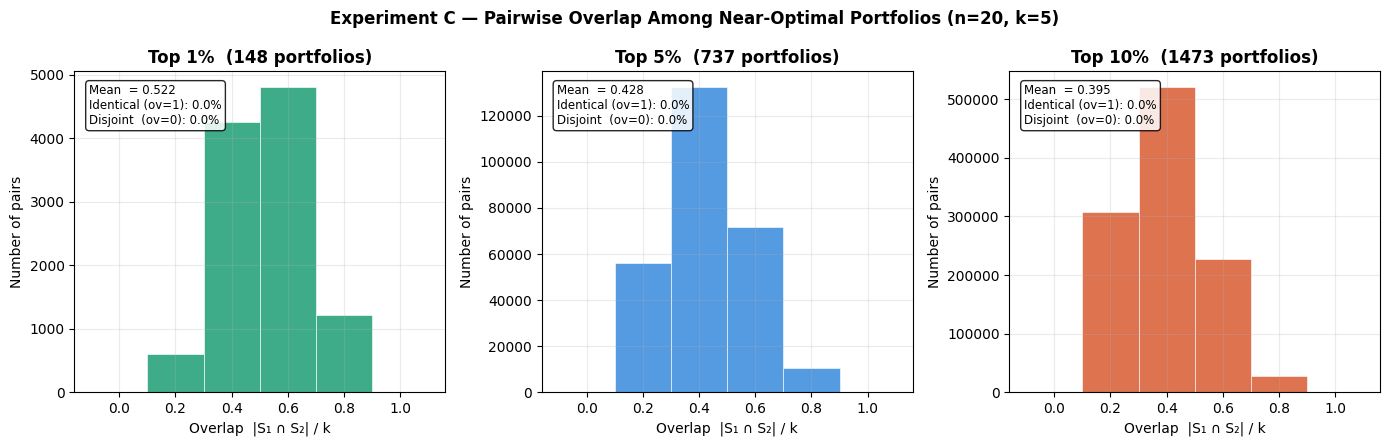

Saved: experiment_C_overlap.png


In [9]:
# =============================================================================
# EXPERIMENT G — Solution Landscape & OGP-style Overlap Analysis
# Fix n=20, k=5. Enumerate all C(20,5)=15,504 portfolios.
#
# Part 1: Return distribution histogram.
# Part 2: Pairwise overlap among near-optimal portfolios.
# =============================================================================
 
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from math import comb
 
# assumes mu_ann, Sigma, sigma2_max, portfolio_return, portfolio_variance
# are already defined (as in your existing notebook)
 
n_C, k_C = 20, 5
mu_C  = mu_ann[:n_C]
Sig_C = Sigma[:n_C, :n_C]
 
# --- enumerate every portfolio ---
print(f"Enumerating all C({n_C},{k_C}) = {comb(n_C,k_C):,} portfolios...")
all_rets, all_vars, all_subs = [], [], []
for sub in combinations(range(n_C), k_C):
    all_rets.append(portfolio_return(sub, mu_C))
    all_vars.append(portfolio_variance(sub, Sig_C))
    all_subs.append(sub)
 
all_rets = np.array(all_rets)
all_vars = np.array(all_vars)
 
feasible  = all_vars <= sigma2_max
feas_rets = all_rets[feasible]
feas_subs = [s for s, f in zip(all_subs, feasible) if f]
optimal_ret = feas_rets.max()
 
print(f"Feasible portfolios : {feasible.sum():,} / {len(all_rets):,} ({100*feasible.mean():.1f}%)")
print(f"Optimal return      : {optimal_ret:.4f}")
 
 
# ── Part 1: return distribution ───────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Experiment C — Solution Landscape (n=20, k=5)', fontsize=13, fontweight='bold')
 
# left: full feasible return distribution
ax = axes[0]
counts, bin_edges, patches = ax.hist(
    feas_rets, bins=60, color='#5B8DB8', edgecolor='white', linewidth=0.4, alpha=0.85
)
 
top1_thresh = np.percentile(feas_rets, 99)
for patch, left in zip(patches, bin_edges[:-1]):
    if left >= top1_thresh:
        patch.set_facecolor('#D85A30')
        patch.set_alpha(0.9)
 
ax.axvline(optimal_ret, color='black',   linewidth=1.8, linestyle='--', label=f'Optimal  ({optimal_ret:.3f})')
ax.axvline(top1_thresh, color='#D85A30', linewidth=1.4, linestyle=':',  label=f'Top 1%   ({top1_thresh:.3f})')
ax.set_xlabel('Annualized portfolio return')
ax.set_ylabel('Number of portfolios')
ax.set_title('Distribution of feasible portfolio returns')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
 
iqr = np.percentile(feas_rets, 75) - np.percentile(feas_rets, 25)
gap = optimal_ret - top1_thresh
ax.text(0.03, 0.97,
        f'Gap (opt − top-1%) = {gap:.4f}\nIQR = {iqr:.4f}\nGap/IQR = {gap/iqr:.2f}x',
        transform=ax.transAxes, va='top', fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
 
# right: zoom into the top-5% tail
ax2 = axes[1]
top5_thresh = np.percentile(feas_rets, 95)
ax2.hist(feas_rets[feas_rets >= top5_thresh], bins=30,
         color='#D85A30', edgecolor='white', linewidth=0.4, alpha=0.85)
ax2.axvline(optimal_ret, color='black', linewidth=1.8, linestyle='--', label='Optimal')
ax2.set_xlabel('Annualized portfolio return')
ax2.set_ylabel('Number of portfolios')
ax2.set_title('Tail zoom: top 5% of feasible portfolios')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25)
 
plt.tight_layout()
plt.savefig('experiment_C_landscape.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: experiment_C_landscape.png")
 
 
# ── Part 2: pairwise overlap among near-optimal portfolios ────────────────────
#
# Overlap between two size-k subsets S1, S2 = |S1 ∩ S2| / k.
# Possible values: 0, 1/k, 2/k, ..., 1.
#
# OGP signature: bimodal distribution — mass near 0 AND near 1, gap in between.
# Unimodal near 1: near-optimal portfolios are clustered (easy landscape).
 
top_pcts = [1, 5, 10]
overlap_results = {}
 
for pct in top_pcts:
    thresh       = np.percentile(feas_rets, 100 - pct)
    top_idx      = np.where(feas_rets >= thresh)[0]
    top_sets     = [set(feas_subs[i]) for i in top_idx]
    pairs        = list(combinations(range(len(top_sets)), 2))
    overlaps     = np.array([len(top_sets[i] & top_sets[j]) / k_C for i, j in pairs])
    overlap_results[pct] = overlaps
    print(f"Top {pct:2d}%: {len(top_sets):4d} portfolios, {len(pairs):6,} pairs | "
          f"mean overlap={overlaps.mean():.3f}  median={np.median(overlaps):.3f}  "
          f"std={overlaps.std():.3f}")
 
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)
fig.suptitle('Experiment C — Pairwise Overlap Among Near-Optimal Portfolios (n=20, k=5)',
             fontsize=12, fontweight='bold')
 
colors    = ['#1D9E75', '#378ADD', '#D85A30']
tick_vals = [i / k_C for i in range(k_C + 1)]
 
for ax, pct, col in zip(axes, top_pcts, colors):
    ov        = overlap_results[pct]
    bin_edges = [-0.5/k_C + v for v in tick_vals] + [1 + 0.5/k_C]
    ax.hist(ov, bins=bin_edges, color=col, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.set_xticks(tick_vals)
    ax.set_xticklabels([f'{v:.1f}' for v in tick_vals])
    ax.set_xlabel('Overlap  |S₁ ∩ S₂| / k')
    ax.set_ylabel('Number of pairs')
    n_ports = (feas_rets >= np.percentile(feas_rets, 100 - pct)).sum()
    ax.set_title(f'Top {pct}%  ({n_ports} portfolios)', fontweight='bold')
    ax.grid(True, alpha=0.25)
    ax.text(0.04, 0.96,
            f'Mean  = {ov.mean():.3f}\n'
            f'Identical (ov=1): {100*(ov==1.0).mean():.1f}%\n'
            f'Disjoint  (ov=0): {100*(ov==0.0).mean():.1f}%',
            transform=ax.transAxes, va='top', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
 
plt.tight_layout()
plt.savefig('experiment_C_overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: experiment_C_overlap.png")

Train: 2020-01-03 to 2022-12-30  (755 days)
Test : 2023-01-03  to 2025-12-30   (751 days)

n=10 | in-sample gap = +1.93%  |  OOS gap = -3.26%  |  opt OOS = 0.1127  greedy OOS = 0.1163
n=15 | in-sample gap = +0.00%  |  OOS gap = +0.00%  |  opt OOS = 0.1875  greedy OOS = 0.1875
n=20 | in-sample gap = +2.77%  |  OOS gap = +30.97%  |  opt OOS = 0.2545  greedy OOS = 0.1757
n=25 | in-sample gap = +10.95%  |  OOS gap = +10.39%  |  opt OOS = 0.2028  greedy OOS = 0.1818
n=30 | in-sample gap = +7.22%  |  OOS gap = +46.86%  |  opt OOS = 0.2334  greedy OOS = 0.1241


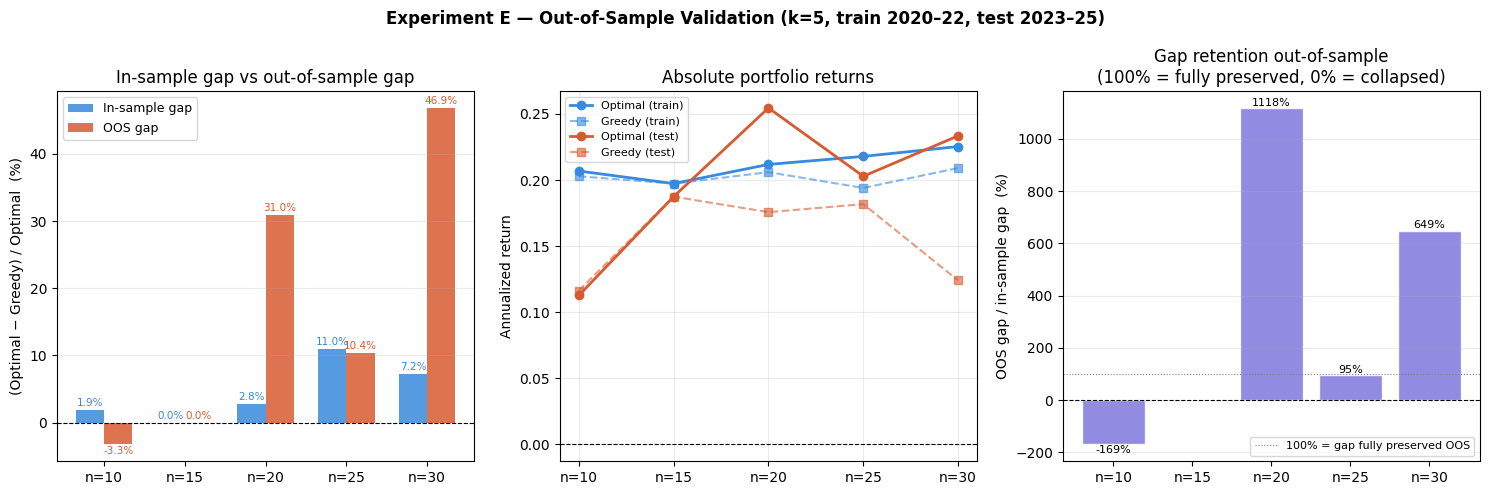

Saved: experiment_E.png


In [ ]:
# =============================================================================
# EXPERIMENT H — Out-of-Sample Validation
#
# Question: does finding the brute-force optimal in-sample portfolio actually
# matter? If estimation noise swamps the in-sample optimality gap, then the
# computational hardness of the problem is practically irrelevant.
#
# Setup:
#   Train: 2020-01-01 to 2022-12-31  (fit mu, Sigma, select portfolios)
#   Test:  2023-01-01 to 2025-12-31  (evaluate those same portfolios)
#
# For each n in {10, 15, 20, 25, 30}, k=5:
#   - Brute-force optimal portfolio chosen on train data
#   - Greedy portfolio chosen on train data
#   - Both evaluated on test data (using test-period realized returns)
#   - Compare in-sample gap vs out-of-sample gap
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from math import comb

# assumes `returns` DataFrame is already loaded (log returns, DatetimeIndex)
# assumes portfolio_return, portfolio_variance, brute_force, greedy are defined

# --- train/test split ---
train = returns.loc[:'2022-12-31']
test  = returns.loc['2023-01-01':]

print(f"Train: {train.index[0].date()} to {train.index[-1].date()}  ({len(train)} days)")
print(f"Test : {test.index[0].date()}  to {test.index[-1].date()}   ({len(test)} days)\n")

# annualized stats from each period
mu_train    = train.mean().values * 252
Sigma_train = train.cov().values

mu_test     = test.mean().values * 252   # realized returns in test window

# --- run for each n ---
ns = [10, 15, 20, 25, 30]
k  = 5
results_E = []

for n in ns:
    mu_tr  = mu_train[:n]
    Sig_tr = Sigma_train[:n, :n]
    mu_te  = mu_test[:n]

    # sigma2_max from training data (same rule as before: median portfolio variance)
    all_vars_tr = [portfolio_variance(sub, Sig_tr) for sub in combinations(range(n), k)]
    s2max = np.median(all_vars_tr)

    # brute-force optimal on training data
    opt_sub, opt_ret_train, _, all_ports = brute_force(n, k, mu_tr, Sig_tr, s2max)

    # greedy on training data
    g_sub, g_ret_train, used_fb = greedy(n, k, mu_tr, Sig_tr, s2max)

    # in-sample gap
    if used_fb or opt_sub is None:
        in_sample_gap = np.nan
    else:
        in_sample_gap = (opt_ret_train - g_ret_train) / abs(opt_ret_train) * 100

    # out-of-sample returns: apply the SAME portfolio weights to test-period mu
    # (equal-weight portfolio of the selected stocks, evaluated on test returns)
    if opt_sub is not None:
        opt_ret_test = portfolio_return(opt_sub, mu_te)
    else:
        opt_ret_test = np.nan

    if not used_fb:
        g_ret_test = portfolio_return(g_sub, mu_te)
        oos_gap    = (opt_ret_test - g_ret_test) / abs(opt_ret_test) * 100 \
                     if not np.isnan(opt_ret_test) else np.nan
    else:
        g_ret_test = np.nan
        oos_gap    = np.nan

    # also record: what fraction of ALL n-choose-k portfolios beat the greedy OOS?
    # this shows whether greedy happened to get "lucky" out-of-sample
    all_oos_rets = np.array([portfolio_return(p[0], mu_te) for p in all_ports
                             if p[2] <= s2max])   # feasible in-sample only
    pct_beating_greedy_oos = (all_oos_rets > g_ret_test).mean() * 100 \
                              if (not used_fb and len(all_oos_rets) > 0) else np.nan

    results_E.append({
        'n':                      n,
        'n_combos':               comb(n, k),
        'in_sample_gap_%':        in_sample_gap,
        'oos_gap_%':              oos_gap,
        'opt_ret_train':          opt_ret_train,
        'g_ret_train':            g_ret_train,
        'opt_ret_test':           opt_ret_test,
        'g_ret_test':             g_ret_test,
        'pct_feas_beating_g_oos': pct_beating_greedy_oos,
    })

    print(f"n={n:2d} | in-sample gap = {in_sample_gap:+.2f}%  |  "
          f"OOS gap = {oos_gap:+.2f}%  |  "
          f"opt OOS = {opt_ret_test:.4f}  greedy OOS = {g_ret_test:.4f}")


# --- plot ---
ns_arr       = np.array([r['n']               for r in results_E])
is_gaps      = np.array([r['in_sample_gap_%'] for r in results_E])
oos_gaps     = np.array([r['oos_gap_%']        for r in results_E])
opt_te       = np.array([r['opt_ret_test']     for r in results_E])
g_te         = np.array([r['g_ret_test']       for r in results_E])
opt_tr       = np.array([r['opt_ret_train']    for r in results_E])
g_tr         = np.array([r['g_ret_train']      for r in results_E])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Experiment H — Out-of-Sample Validation (k=5, train 2020–22, test 2023–25)',
             fontsize=12, fontweight='bold')

x = np.arange(len(ns_arr))
w = 0.35

# left: in-sample gap vs out-of-sample gap side by side
ax = axes[0]
bars1 = ax.bar(x - w/2, is_gaps,  width=w, color='#378ADD', alpha=0.85, label='In-sample gap')
bars2 = ax.bar(x + w/2, oos_gaps, width=w, color='#D85A30', alpha=0.85, label='OOS gap')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x); ax.set_xticklabels([f'n={n}' for n in ns_arr])
ax.set_ylabel('(Optimal − Greedy) / Optimal  (%)')
ax.set_title('In-sample gap vs out-of-sample gap')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25, axis='y')
# annotate each bar with its value
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=7.5, color='#378ADD')
for bar in bars2:
    h = bar.get_height()
    va = 'bottom' if h >= 0 else 'top'
    offset = 0.3 if h >= 0 else -0.3
    ax.text(bar.get_x() + bar.get_width()/2, h + offset,
            f'{h:.1f}%', ha='center', va=va, fontsize=7.5, color='#D85A30')

# middle: absolute returns in train vs test for both portfolios
ax2 = axes[1]
ax2.plot(ns_arr, opt_tr, 'o-', color='#378ADD', linewidth=2,  label='Optimal (train)')
ax2.plot(ns_arr, g_tr,   's--', color='#378ADD', linewidth=1.5, alpha=0.6, label='Greedy (train)')
ax2.plot(ns_arr, opt_te, 'o-', color='#D85A30', linewidth=2,  label='Optimal (test)')
ax2.plot(ns_arr, g_te,   's--', color='#D85A30', linewidth=1.5, alpha=0.6, label='Greedy (test)')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(ns_arr); ax2.set_xticklabels([f'n={n}' for n in ns_arr])
ax2.set_ylabel('Annualized return')
ax2.set_title('Absolute portfolio returns')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.25)

# right: gap collapse — show the ratio OOS gap / in-sample gap
ax3 = axes[2]
is_gaps_safe  = np.where(np.abs(is_gaps) < 1e-10, np.nan, is_gaps)
gap_retention = oos_gaps / is_gaps_safe * 100
ax3.bar(x, gap_retention, color='#7F77DD', alpha=0.85, edgecolor='white')
ax3.axhline(0,   color='black', linewidth=0.8, linestyle='--')
ax3.axhline(100, color='gray',  linewidth=0.8, linestyle=':',
            label='100% = gap fully preserved OOS')
ax3.set_xticks(x); ax3.set_xticklabels([f'n={n}' for n in ns_arr])
ax3.set_ylabel('OOS gap / in-sample gap  (%)')
ax3.set_title('Gap retention out-of-sample\n(100% = fully preserved, 0% = collapsed)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.25, axis='y')
for i, (bar, val) in enumerate(zip(ax3.patches, gap_retention)):
    h = bar.get_height()
    va = 'bottom' if h >= 0 else 'top'
    ax3.text(bar.get_x() + bar.get_width()/2, h + (1 if h >= 0 else -1),
             f'{val:.0f}%', ha='center', va=va, fontsize=8)

plt.tight_layout()
plt.savefig('experiment_E.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: experiment_E.png")